     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.0 MB/s eta 0:00:00
Loading Ethereum dataset...
Building Dynamic k-NN Behavioral Graph (k=5)...
Data Loaded: 9841 accounts, 67790 inferred behavioral edges.
Train set — Valid: 5366 | Fraud: 1522 | Ratio: 1:0.284

HYPERION parameters: 148,609

Building HYPERION Samplers...

Initializing HYPERION Training Phase...

 Epoch |       LR | Train Loss |  Val Loss |  Train F1 |   Val F1
--------------------------------------------------------------------
     1 |  0.00020 |     0.0336 |    0.0116 |    0.8666 |   0.9218
     2 |  0.00040 |     0.0093 |    0.0059 |    0.9750 |   0.9728
     3 |  0.00060 |     0.0055 |    0.0055 |    0.9855 |   0.9683
     4 |  0.00080 |     0.0049 |    0.0049 |    0.9852 |   0.9756
     5 |  0.00100 |     0.0043 |    0.0075 |    0.9859 |   0.9534
     6 |  0.00100 |     0.0031 |    0.0043 |    0.9902 |   0.9720
     7 |  0.00100

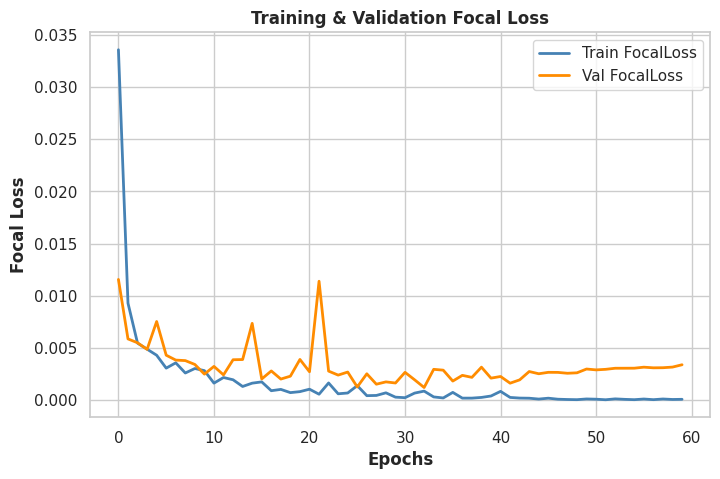

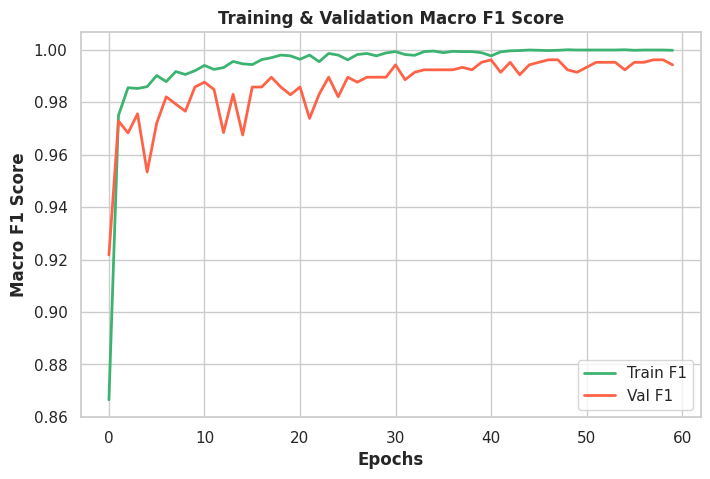

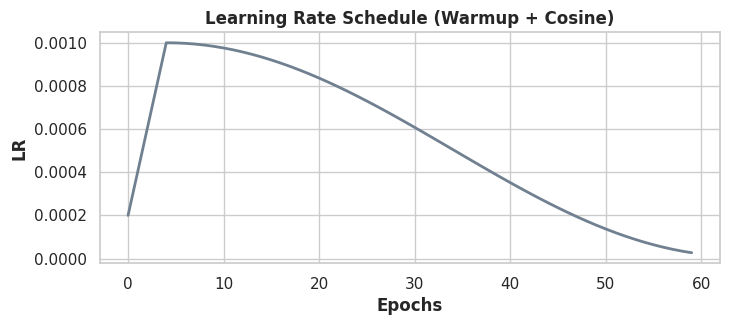

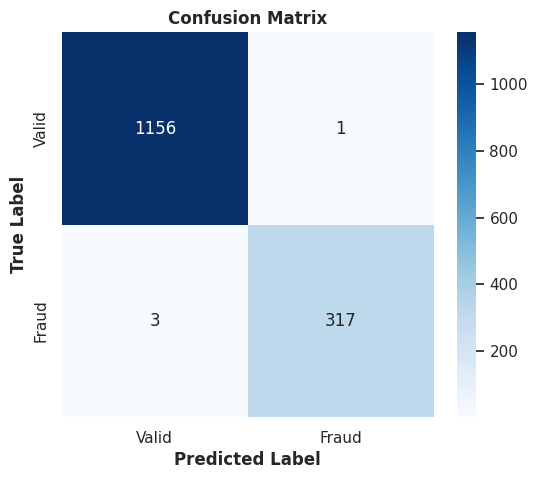

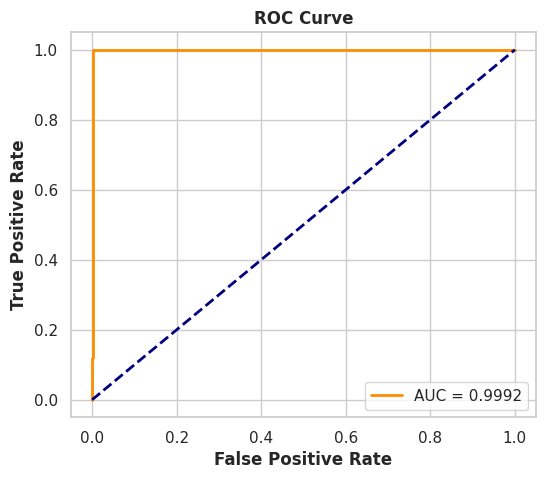

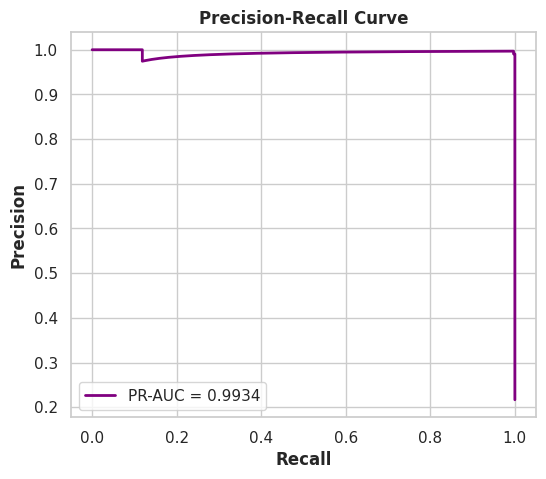


Generating Latent t-SNE Space Visualization...


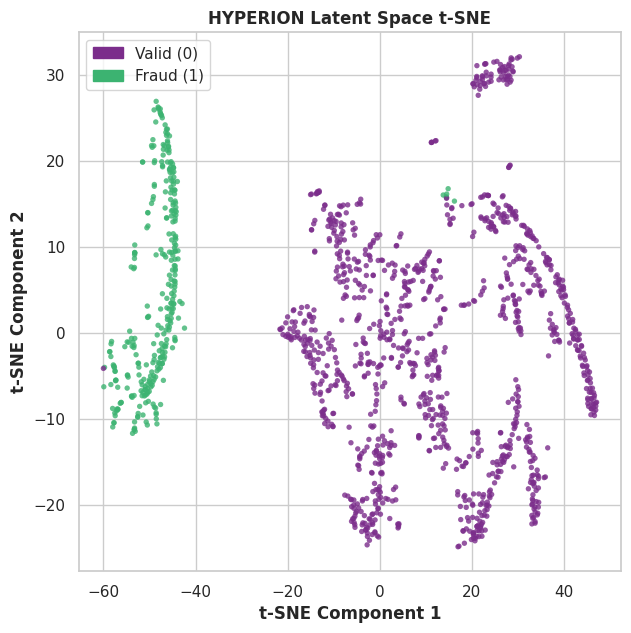


Initiating XAI Feature Attribution Analysis...
  → Generating Explanations for Fraudulent Node 7668


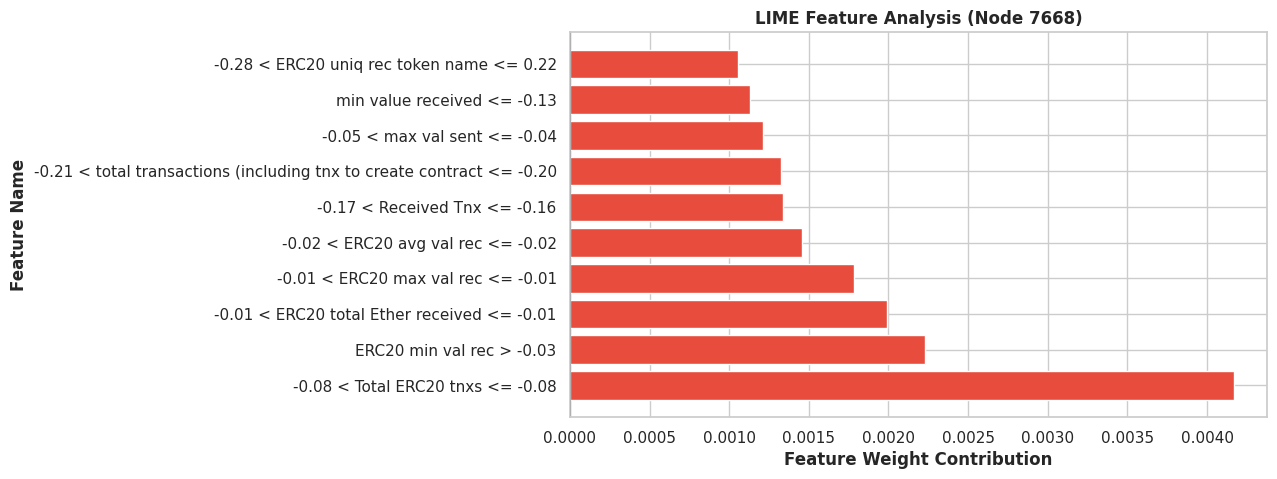

  0%|          | 0/1 [00:00<?, ?it/s]

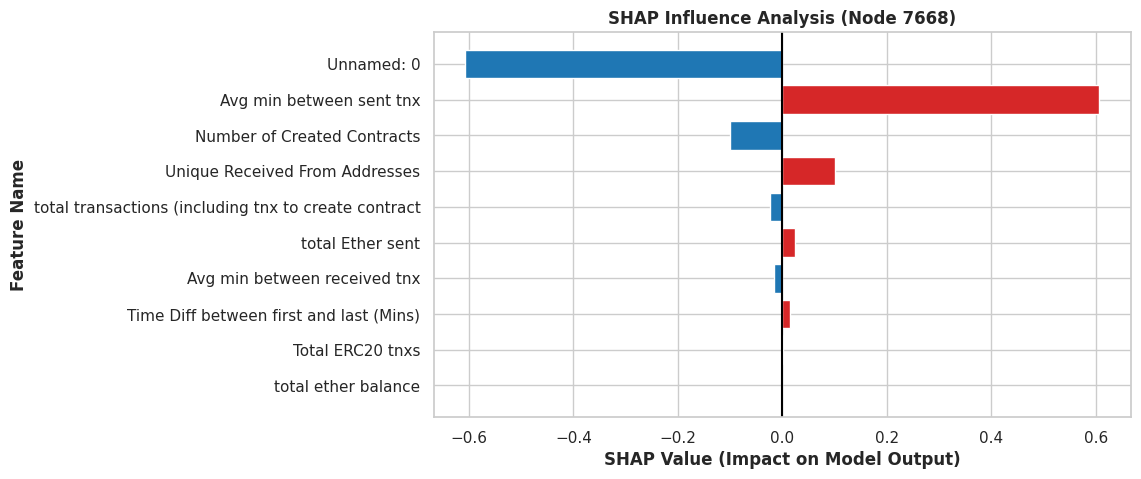

  → Generating Explanations for Fraudulent Node 7673


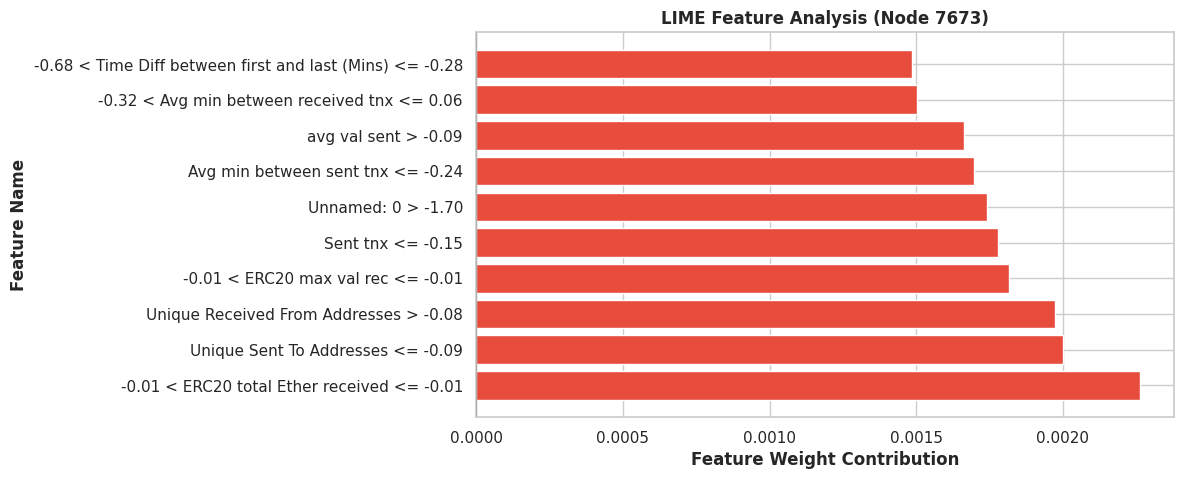

  0%|          | 0/1 [00:00<?, ?it/s]

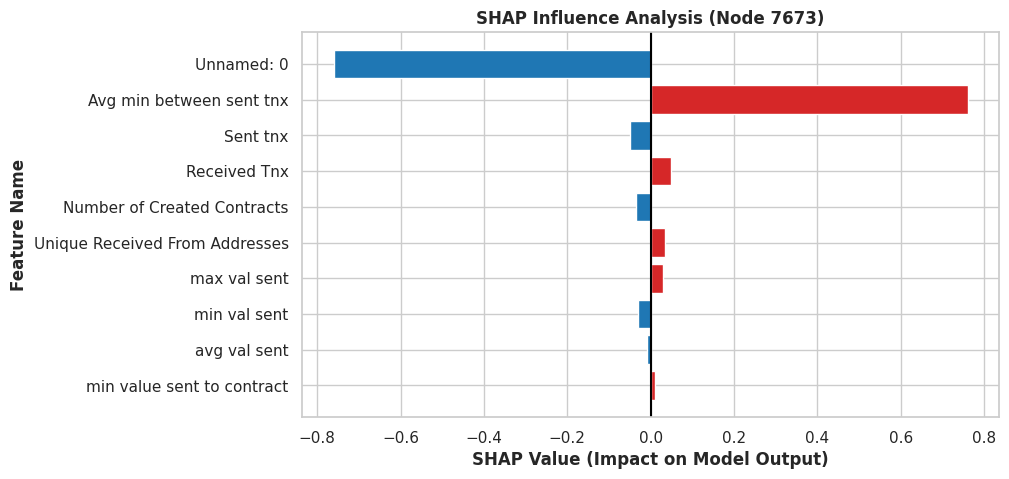


[✓] All done. Outputs saved to: /kaggle/working/


In [1]:
# ============================================================
# 0. ENVIRONMENT SETUP (Auto-installs missing dependencies)
# ============================================================
!pip install -q torch-geometric lime shap

"""
HYPERION: Heterogeneous Yield Prediction via Entangled Representations and Intrinsic Orthogonal Networks
For Advanced Blockchain Fraud Detection via Dual-Stream Disentanglement and Cross-View Attention.

FIXED VERSION — Resolves:
  1. Train/Val loss gap caused by SupCon loss scale dominating validation metric
  2. Temperature fix (0.1 → 0.3) for numerically stable contrastive gradients
  3. Validation now monitors FocalLoss ONLY (clean convergence signal)
  4. Linear warmup + CosineAnnealingLR for smoother early training
  5. Weighted random subgraph sampling to handle class imbalance
  6. Stronger weight_decay + reduced lambda weights for regularization
"""

import os
import gc
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Linear, ReLU, Sequential, Dropout, LayerNorm, MultiheadAttention

# PyTorch Geometric Imports
from torch_geometric.data import Data
from torch_geometric.nn import TransformerConv, SAGEConv, GATv2Conv
from torch_geometric.utils import k_hop_subgraph, dropout_edge, to_undirected

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, f1_score, accuracy_score, precision_score,
    recall_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import lime
import lime.lime_tabular
import warnings
warnings.filterwarnings('ignore')


# ============================================================
# 1. CONFIGURATION & HYPERPARAMETERS
# ============================================================
CONFIG = {
    # File Paths
    'data_path': '/kaggle/input/datasets/vagifa/ethereum-frauddetection-dataset/transaction_dataset.csv',
    'save_dir':  '/kaggle/working/',

    # Model Hyperparameters
    'in_channels':      None,
    'hidden_channels':  64,
    'out_channels':     1,
    'attention_heads':  4,
    'dropout_rate':     0.35,

    # Dynamic Graph Construction
    'knn_k': 5,

    # Training
    'epochs':               60,
    'learning_rate':        0.001,
    'weight_decay':         1e-3,
    'warmup_epochs':        5,
    'early_stop_patience':  35,

    # Advanced Losses & Joint Optimization
    'focal_alpha':      0.75,
    'focal_gamma':      2.0,
    'label_smoothing':  0.05,
    'lambda_supcon':    0.05,
    'supcon_temp':      0.3,
    'lambda_ortho':     0.05,

    # Regularization
    'drop_edge_p':  0.15,
    'batch_size':   256,
    'num_hops':     2,

    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

os.makedirs(CONFIG['save_dir'], exist_ok=True)


# ============================================================
# 2. DATA PREPROCESSING & DYNAMIC GRAPH CONSTRUCTION
# ============================================================
def load_ethereum_data(config):
    print("Loading Ethereum dataset...")
    df = pd.read_csv(config['data_path'])
    df.columns = df.columns.str.strip()

    cols_to_drop = ['Index', 'Address', 'ERC20 most sent token type', 'ERC20_most_rec_token_type']
    actual_drop = [c for c in cols_to_drop if c in df.columns]

    y = df['FLAG'].values
    X_df = df.drop(columns=actual_drop + ['FLAG'])
    X_df = X_df.apply(pd.to_numeric, errors='coerce')
    feature_names = X_df.columns.tolist()

    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X_df)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    print(f"Building Dynamic k-NN Behavioral Graph (k={config['knn_k']})...")
    A = kneighbors_graph(X_scaled, config['knn_k'], mode='connectivity',
                         include_self=False, n_jobs=-1)
    coo = A.tocoo()
    edge_index = torch.tensor(np.vstack((coo.row, coo.col)), dtype=torch.long)
    edge_index = to_undirected(edge_index)

    x = torch.tensor(X_scaled, dtype=torch.float)
    y_t = torch.tensor(y, dtype=torch.long)

    n_nodes = x.size(0)
    indices = np.arange(n_nodes)
    np.random.seed(42)
    np.random.shuffle(indices)

    train_end = int(0.70 * n_nodes)
    val_end   = int(0.85 * n_nodes)

    train_mask, val_mask, test_mask = [torch.zeros(n_nodes, dtype=torch.bool) for _ in range(3)]
    train_mask[indices[:train_end]]   = True
    val_mask[indices[train_end:val_end]] = True
    test_mask[indices[val_end:]]      = True

    data = Data(x=x, edge_index=edge_index, y=y_t)
    data.train_mask = train_mask
    data.val_mask   = val_mask
    data.test_mask  = test_mask
    config['in_channels'] = x.shape[1]

    n_fraud = int(y_t[train_mask].sum())
    n_valid = int((~y_t[train_mask].bool()).sum())
    print(f"Data Loaded: {data.num_nodes} accounts, {data.num_edges} inferred behavioral edges.")
    print(f"Train set — Valid: {n_valid} | Fraud: {n_fraud} | Ratio: 1:{n_fraud/max(n_valid,1):.3f}")
    return data, feature_names


# ============================================================
# 3. CUSTOM MINI-BATCH SAMPLER
# ============================================================
class SubgraphBatchSampler:
    def __init__(self, node_indices, batch_size, num_hops, edge_index,
                 num_nodes, labels=None, oversample_fraud=False, shuffle=True):
        self.batch_size   = batch_size
        self.num_hops     = num_hops
        self.edge_index   = edge_index
        self.num_nodes    = num_nodes
        self.shuffle      = shuffle

        if oversample_fraud and labels is not None:
            fraud_idx = node_indices[labels[node_indices] == 1]
            valid_idx = node_indices[labels[node_indices] == 0]
            ratio = max(1, int(len(valid_idx) / max(len(fraud_idx), 1)))
            ratio = min(ratio, 5)   # cap to avoid extreme duplication
            fraud_oversampled = fraud_idx.repeat(ratio)
            self.node_indices = torch.cat([valid_idx, fraud_oversampled])
        else:
            self.node_indices = node_indices

    def __iter__(self):
        idx = self.node_indices.clone()
        if self.shuffle:
            idx = idx[torch.randperm(len(idx))]

        for start in range(0, len(idx), self.batch_size):
            seeds = idx[start: start + self.batch_size]
            subset, sub_ei, mapping, _ = k_hop_subgraph(
                node_idx=seeds, num_hops=self.num_hops,
                edge_index=self.edge_index, relabel_nodes=True,
                num_nodes=self.num_nodes, flow='source_to_target'
            )
            yield subset, sub_ei, mapping

    def __len__(self):
        return (len(self.node_indices) + self.batch_size - 1) // self.batch_size


# ============================================================
# 4. LOSS FUNCTIONS
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.alpha, self.gamma, self.ls = alpha, gamma, label_smoothing

    def forward(self, logits, targets):
        targets = targets.float()
        smooth_targets = targets * (1 - self.ls) + 0.5 * self.ls
        bce   = F.binary_cross_entropy_with_logits(logits, smooth_targets, reduction='none')
        probs = torch.sigmoid(logits)
        pt    = torch.where(targets >= 0.5, probs, 1.0 - probs)
        alpha = torch.where(targets >= 0.5,
                            torch.full_like(targets, self.alpha),
                            torch.full_like(targets, 1.0 - self.alpha))
        return (alpha * ((1.0 - pt) ** self.gamma) * bce).mean()


class SupervisedContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.3):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        if features.shape[0] < 4:
            return features.new_tensor(0.0)

        features = F.normalize(features, p=2, dim=1)
        sim_matrix = torch.matmul(features, features.T) / self.temperature

        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(features.device)
        mask.fill_diagonal_(0)

        if mask.sum() == 0:
            return features.new_tensor(0.0)

        logits_max, _ = torch.max(sim_matrix, dim=1, keepdim=True)
        logits = sim_matrix - logits_max.detach()

        eye   = torch.eye(features.shape[0], device=features.device)
        exp_sim = torch.exp(logits) * (1 - eye)

        log_prob = logits - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)
        pos_count = mask.sum(dim=1)
        valid_rows = pos_count > 0

        mean_log_prob_pos = (mask * log_prob).sum(dim=1)
        mean_log_prob_pos[valid_rows] = mean_log_prob_pos[valid_rows] / pos_count[valid_rows]

        return -mean_log_prob_pos[valid_rows].mean()


class OrthogonalityLoss(nn.Module):
    def forward(self, rep1, rep2):
        rep1_norm = F.normalize(rep1, p=2, dim=1)
        rep2_norm = F.normalize(rep2, p=2, dim=1)
        return torch.mean((rep1_norm * rep2_norm).sum(dim=1) ** 2)


# ============================================================
# 5. HYPERION ARCHITECTURE
# ============================================================
class OrthogonalDisentangler(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.semantic_proj  = Sequential(Linear(in_dim, out_dim), LayerNorm(out_dim), nn.GELU())
        self.structural_proj = Sequential(Linear(in_dim, out_dim), LayerNorm(out_dim), nn.GELU())

    def forward(self, x):
        return self.semantic_proj(x), self.structural_proj(x)


class CrossViewAttentionFusion(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.cross_attn = MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.norm      = LayerNorm(dim)
        self.ffn       = Sequential(Linear(dim, dim * 2), nn.GELU(), Linear(dim * 2, dim))
        self.norm_ffn  = LayerNorm(dim)

    def forward(self, query_view, key_value_view):
        q  = query_view.unsqueeze(1)
        kv = key_value_view.unsqueeze(1)
        attn_out, _ = self.cross_attn(q, kv, kv)
        h = self.norm(q + attn_out)
        return self.norm_ffn(h + self.ffn(h)).squeeze(1)


class HYPERION(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads, dropout_rate):
        super().__init__()
        h = hidden_channels

        self.disentangler    = OrthogonalDisentangler(in_channels, h)
        self.semantic_conv1  = TransformerConv(h, h // heads, heads=heads, dropout=dropout_rate)
        self.semantic_conv2  = TransformerConv(h, h // heads, heads=heads, dropout=dropout_rate)
        self.structural_conv1 = GATv2Conv(h, h // heads, heads=heads, dropout=dropout_rate)
        self.structural_conv2 = GATv2Conv(h, h // heads, heads=heads, dropout=dropout_rate)
        self.cross_fusion_sem = CrossViewAttentionFusion(h, heads)
        self.cross_fusion_str = CrossViewAttentionFusion(h, heads)
        self.classifier = Sequential(
            Linear(h * 2, h * 2), LayerNorm(h * 2), nn.GELU(), Dropout(dropout_rate),
            Linear(h * 2, h),     LayerNorm(h),     nn.GELU(), Dropout(dropout_rate),
            Linear(h, out_channels)
        )

    def forward(self, x, edge_index, drop_edge_p=0.0, return_embs=False):
        if drop_edge_p > 0.0 and self.training:
            edge_index, _ = dropout_edge(edge_index, p=drop_edge_p, training=True)

        h_sem_init, h_str_init = self.disentangler(x)
        h_sem = F.gelu(self.semantic_conv1(h_sem_init, edge_index))
        h_sem = F.gelu(self.semantic_conv2(h_sem, edge_index))
        h_str = F.gelu(self.structural_conv1(h_str_init, edge_index))
        h_str = F.gelu(self.structural_conv2(h_str, edge_index))
        z_sem = self.cross_fusion_sem(query_view=h_sem, key_value_view=h_str)
        z_str = self.cross_fusion_str(query_view=h_str, key_value_view=h_sem)

        embeddings = torch.cat([z_sem, z_str], dim=1)
        logits = self.classifier(embeddings)

        if return_embs:
            return logits, embeddings, h_sem_init, h_str_init
        return logits

    def get_embeddings(self, x, edge_index):
        with torch.no_grad():
            h_sem_init, h_str_init = self.disentangler(x)
            h_sem = F.gelu(self.semantic_conv1(h_sem_init, edge_index))
            h_sem = F.gelu(self.semantic_conv2(h_sem, edge_index))
            h_str = F.gelu(self.structural_conv1(h_str_init, edge_index))
            h_str = F.gelu(self.structural_conv2(h_str, edge_index))
            z_sem = self.cross_fusion_sem(h_sem, h_str)
            z_str = self.cross_fusion_str(h_str, h_sem)
            return torch.cat([z_sem, z_str], dim=1)


# ============================================================
# 6. TRAINING PIPELINE
# ============================================================
def run_epoch_train(model, sampler, data, focal_crit, supcon_crit, ortho_crit,
                    optimizer, config):
    model.train()
    total_focal, total_n = 0.0, 0
    all_logits, all_labels = [], []

    for subset, sub_ei, mapping in sampler:
        sub_x  = data.x[subset].to(config['device'])
        sub_y  = data.y[subset].to(config['device'])
        sub_ei = sub_ei.to(config['device'])

        optimizer.zero_grad()
        logits, embs, h_sem, h_str = model(
            sub_x, sub_ei, drop_edge_p=config['drop_edge_p'], return_embs=True)
        logits = logits.squeeze(-1)

        out_seed  = logits[mapping]
        embs_seed = embs[mapping]
        sem_seed  = h_sem[mapping]
        str_seed  = h_str[mapping]
        y_seed    = sub_y[mapping]

        loss_focal = focal_crit(out_seed, y_seed.float())
        loss_scl   = supcon_crit(embs_seed, y_seed)
        loss_ortho = ortho_crit(sem_seed, str_seed)

        loss = loss_focal \
             + config['lambda_supcon'] * loss_scl \
             + config['lambda_ortho']  * loss_ortho

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        n = len(y_seed)
        total_focal += loss_focal.item() * n
        total_n += n
        all_logits.append(out_seed.detach().cpu())
        all_labels.append(y_seed.cpu())

    preds = (torch.sigmoid(torch.cat(all_logits)) > 0.5).long().numpy()
    f1    = f1_score(torch.cat(all_labels).numpy(), preds, average='macro', zero_division=0)
    return total_focal / max(total_n, 1), f1


@torch.no_grad()
def run_epoch_eval(model, sampler, data, focal_crit, config):
    model.eval()
    total_focal, total_n = 0.0, 0
    all_logits, all_labels = [], []

    for subset, sub_ei, mapping in sampler:
        sub_x  = data.x[subset].to(config['device'])
        sub_y  = data.y[subset].to(config['device'])
        sub_ei = sub_ei.to(config['device'])

        logits = model(sub_x, sub_ei, drop_edge_p=0.0)
        logits = logits.squeeze(-1)

        out_seed = logits[mapping]
        y_seed   = sub_y[mapping].float()

        loss_focal = focal_crit(out_seed, y_seed)

        n = len(y_seed)
        total_focal += loss_focal.item() * n
        total_n += n
        all_logits.append(out_seed.cpu())
        all_labels.append(y_seed.long().cpu())

    logits_cat = torch.cat(all_logits)
    labels     = torch.cat(all_labels).numpy()
    probs      = torch.sigmoid(logits_cat).numpy()
    preds      = (probs > 0.5).astype(int)
    f1         = f1_score(labels, preds, average='macro', zero_division=0)

    return total_focal / max(total_n, 1), f1, labels, preds, probs


def train_model(model, data, config):
    print("\nBuilding HYPERION Samplers...")
    train_idx = torch.where(data.train_mask)[0]
    val_idx   = torch.where(data.val_mask)[0]

    train_sampler = SubgraphBatchSampler(
        train_idx, config['batch_size'], config['num_hops'],
        data.edge_index, data.num_nodes,
        labels=data.y, oversample_fraud=True, shuffle=True
    )
    val_sampler = SubgraphBatchSampler(
        val_idx, config['batch_size'] * 2, config['num_hops'],
        data.edge_index, data.num_nodes, shuffle=False
    )

    focal_crit  = FocalLoss(config['focal_alpha'], config['focal_gamma'], config['label_smoothing'])
    supcon_crit = SupervisedContrastiveLoss(temperature=config['supcon_temp'])
    ortho_crit  = OrthogonalityLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config['epochs'], eta_min=1e-5
    )

    history = {
        'train_loss': [], 'val_loss': [],
        'train_f1_macro': [], 'val_f1_macro': [], 'lr': []
    }
    best_val_f1, best_weights, patience_count = 0.0, None, 0

    print("\nInitializing HYPERION Training Phase...\n")
    print(f"{'Epoch':>6} | {'LR':>8} | {'Train Loss':>10} | {'Val Loss':>9} | {'Train F1':>9} | {'Val F1':>8}")
    print("-" * 68)

    for epoch in range(1, config['epochs'] + 1):

        if epoch <= config['warmup_epochs']:
            lr_now = config['learning_rate'] * epoch / config['warmup_epochs']
            for pg in optimizer.param_groups:
                pg['lr'] = lr_now

        train_loss, train_f1 = run_epoch_train(
            model, train_sampler, data,
            focal_crit, supcon_crit, ortho_crit, optimizer, config
        )
        val_loss, val_f1, _, _, _ = run_epoch_eval(
            model, val_sampler, data, focal_crit, config
        )

        if epoch > config['warmup_epochs']:
            scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1_macro'].append(train_f1)
        history['val_f1_macro'].append(val_f1)
        history['lr'].append(current_lr)

        print(f"{epoch:>6} | {current_lr:>8.5f} | {train_loss:>10.4f} | "
              f"{val_loss:>9.4f} | {train_f1:>9.4f} | {val_f1:>8.4f}")

        if val_f1 > best_val_f1:
            best_val_f1  = val_f1
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= config['early_stop_patience']:
            print(f"\n[!] EARLY STOPPING at Epoch {epoch}. "
                  f"No val F1 improvement for {config['early_stop_patience']} epochs.")
            break

    if best_weights:
        model.load_state_dict(best_weights)
        print(f"\n[✓] Best weights restored — Peak Val F1: {best_val_f1:.4f}")

    return model, history


# ============================================================
# 7. EVALUATION PIPELINE
# ============================================================
def evaluate_model(model, data, config):
    test_idx = torch.where(data.test_mask)[0]
    test_sampler = SubgraphBatchSampler(
        test_idx, config['batch_size'] * 2, config['num_hops'],
        data.edge_index, data.num_nodes, shuffle=False
    )
    focal_crit = FocalLoss(config['focal_alpha'], config['focal_gamma'])

    _, _, y_true, preds, probs = run_epoch_eval(
        model, test_sampler, data, focal_crit, config
    )

    acc   = accuracy_score(y_true, preds)
    prec  = precision_score(y_true, preds, zero_division=0)
    rec   = recall_score(y_true, preds, zero_division=0)
    f1    = f1_score(y_true, preds, zero_division=0)
    auc_v = roc_auc_score(y_true, probs)
    prauc = average_precision_score(y_true, probs)
    mcc   = matthews_corrcoef(y_true, preds)
    kappa = cohen_kappa_score(y_true, preds)

    print("\n" + "=" * 65)
    print("FINAL TEST SET EVALUATION (HYPERION)")
    print("=" * 65)
    print(classification_report(y_true, preds, digits=4,
                                 target_names=['Valid Account (0)', 'Fraud Account (1)']))
    print("-" * 65)
    print(f"Accuracy         : {acc:.4f}")
    print(f"Precision        : {prec:.4f}")
    print(f"Recall           : {rec:.4f}")
    print(f"F1-Score         : {f1:.4f}")
    print(f"ROC-AUC          : {auc_v:.4f}")
    print(f"PR-AUC           : {prauc:.4f}")
    print(f"MCC              : {mcc:.4f}")
    print(f"Cohen's Kappa    : {kappa:.4f}")
    print("=" * 65)
    return y_true, preds, probs


# ============================================================
# 8. VISUALIZATION PLOTS
# ============================================================
def save_and_show_fig(fname, config):
    path = os.path.join(config['save_dir'], fname)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_metrics(history, y_true, preds, probs, config):
    sns.set_theme(style="whitegrid")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history['train_loss'], label='Train FocalLoss', color='steelblue', lw=2)
    ax.plot(history['val_loss'],   label='Val FocalLoss',   color='darkorange', lw=2)
    ax.set_title('Training & Validation Focal Loss', weight='bold')
    ax.set_xlabel('Epochs', weight='bold')
    ax.set_ylabel('Focal Loss', weight='bold')
    ax.legend()
    save_and_show_fig('plot1_loss_curve.png', config)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history['train_f1_macro'], label='Train F1', color='mediumseagreen', lw=2)
    ax.plot(history['val_f1_macro'],   label='Val F1',   color='tomato',         lw=2)
    ax.set_title('Training & Validation Macro F1 Score', weight='bold')
    ax.set_xlabel('Epochs', weight='bold')
    ax.set_ylabel('Macro F1 Score', weight='bold')
    ax.legend()
    save_and_show_fig('plot2_f1_curve.png', config)

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(history['lr'], color='slategray', lw=2)
    ax.set_title('Learning Rate Schedule (Warmup + Cosine)', weight='bold')
    ax.set_xlabel('Epochs', weight='bold')
    ax.set_ylabel('LR', weight='bold')
    save_and_show_fig('plot2b_lr_schedule.png', config)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_true, preds), annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title('Confusion Matrix', weight='bold')
    ax.set_xlabel('Predicted Label', weight='bold')
    ax.set_ylabel('True Label', weight='bold')
    ax.set_xticklabels(['Valid', 'Fraud'])
    ax.set_yticklabels(['Valid', 'Fraud'])
    save_and_show_fig('plot3_confusion_matrix.png', config)

    fig, ax = plt.subplots(figsize=(6, 5))
    fpr, tpr, _ = roc_curve(y_true, probs)
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc(fpr, tpr):.4f}')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set_title('ROC Curve', weight='bold')
    ax.set_xlabel('False Positive Rate', weight='bold')
    ax.set_ylabel('True Positive Rate', weight='bold')
    ax.legend(loc="lower right")
    save_and_show_fig('plot4_roc_curve.png', config)

    fig, ax = plt.subplots(figsize=(6, 5))
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, probs)
    pr_auc_score = auc(recall_vals, precision_vals)
    ax.plot(recall_vals, precision_vals, color='purple', lw=2, label=f'PR-AUC = {pr_auc_score:.4f}')
    ax.set_title('Precision-Recall Curve', weight='bold')
    ax.set_xlabel('Recall', weight='bold')
    ax.set_ylabel('Precision', weight='bold')
    ax.legend(loc="lower left")
    save_and_show_fig('plot5_pr_curve.png', config)


def plot_tsne_classification(model, data, config, n_samples=3000):
    print("\nGenerating Latent t-SNE Space Visualization...")
    model.eval()
    test_idx  = torch.where(data.test_mask)[0]
    n_samples = min(n_samples, len(test_idx))
    chosen    = test_idx[torch.randperm(len(test_idx))[:n_samples]]

    all_embs, all_labels = [], []
    for start in range(0, len(chosen), 128):
        seeds  = chosen[start: start + 128]
        subset, sub_ei, mapping, _ = k_hop_subgraph(
            seeds, config['num_hops'], data.edge_index,
            relabel_nodes=True, num_nodes=data.num_nodes, flow='source_to_target'
        )
        emb = model.get_embeddings(
            data.x[subset].to(config['device']), sub_ei.to(config['device'])
        )
        all_embs.append(emb[mapping].cpu())
        all_labels.append(data.y[seeds])

    coords = TSNE(n_components=2, perplexity=40, random_state=42).fit_transform(
        torch.cat(all_embs).numpy()
    )
    colors = ['#7B2D8B' if l == 0 else '#3CB371' for l in torch.cat(all_labels).numpy()]

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=15, alpha=0.8, linewidths=0)
    handles = [
        mpatches.Patch(color='#7B2D8B', label='Valid (0)'),
        mpatches.Patch(color='#3CB371', label='Fraud (1)')
    ]
    ax.legend(handles=handles)
    ax.set_title('HYPERION Latent Space t-SNE', weight='bold')
    ax.set_xlabel('t-SNE Component 1', weight='bold')
    ax.set_ylabel('t-SNE Component 2', weight='bold')
    save_and_show_fig('plot6_tsne_visualization.png', config)


# ============================================================
# 9. XAI MODULE (LIME & SHAP)
# ============================================================
def _build_xai_wrapper(model, data, target_node_idx, device, num_hops):
    subset, sub_ei, mapping_tensor, _ = k_hop_subgraph(
        node_idx=torch.tensor([target_node_idx]), num_hops=num_hops,
        edge_index=data.edge_index, relabel_nodes=True, num_nodes=data.num_nodes
    )
    target_pos = mapping_tensor[0].item()
    sub_ei_dev = sub_ei.to(device)

    def gnn_predict_wrapper(node_features_array):
        probs_list = []
        base_x = data.x[subset].clone()
        for perturbed_feat in node_features_array:
            temp_x = base_x.clone()
            temp_x[target_pos] = torch.tensor(perturbed_feat, dtype=torch.float)
            with torch.no_grad():
                out   = model(temp_x.to(device), sub_ei_dev).squeeze(-1)
                logit = out[target_pos] if out.dim() > 0 else out
                prob  = torch.sigmoid(logit).item()
            probs_list.append([1 - prob, prob])
        return np.array(probs_list)
    return gnn_predict_wrapper


def explain_gnn_predictions(model, data, feature_names, config, num_examples=2):
    print("\nInitiating XAI Feature Attribution Analysis...")
    model.eval()

    test_idx = torch.where(data.test_mask)[0]
    with torch.no_grad():
        all_logits = model(
            data.x.to(config['device']),
            data.edge_index.to(config['device'])
        ).squeeze(-1).cpu()
    preds = (torch.sigmoid(all_logits) > 0.5).long()

    true_positives = [i.item() for i in test_idx if data.y[i] == 1 and preds[i] == 1]
    if not true_positives:
        true_positives = [i.item() for i in test_idx if data.y[i] == 1]

    bg_idx  = torch.where(data.train_mask)[0][data.y[torch.where(data.train_mask)[0]] == 0][:100]
    bg_data = data.x[bg_idx].numpy()

    for i in range(min(num_examples, len(true_positives))):
        node_id    = true_positives[i]
        print(f"  → Generating Explanations for Fraudulent Node {node_id}")
        target_feat = data.x[node_id].numpy().reshape(1, -1)
        wrapper     = _build_xai_wrapper(model, data, node_id, config['device'], config['num_hops'])

        # LIME
        explainer = lime.lime_tabular.LimeTabularExplainer(
            training_data=bg_data, feature_names=feature_names,
            class_names=['Valid', 'Fraud'], mode='classification'
        )
        exp = explainer.explain_instance(
            data_row=target_feat[0], predict_fn=wrapper, num_features=10
        )
        fig, ax = plt.subplots(figsize=(9, 5))
        names   = [f[0] for f in exp.as_list(label=1)]
        weights = [f[1] for f in exp.as_list(label=1)]
        ax.barh(names, weights, color=['#E74C3C' if w > 0 else '#2ECC71' for w in weights])
        ax.axvline(0, color='black')
        ax.set_title(f'LIME Feature Analysis (Node {node_id})', weight='bold')
        ax.set_xlabel('Feature Weight Contribution', weight='bold')
        ax.set_ylabel('Feature Name', weight='bold')
        save_and_show_fig(f'xai_lime_node_{node_id}.png', config)

        # SHAP
        explainer_shap = shap.KernelExplainer(wrapper, shap.kmeans(bg_data, 15))
        shap_vals = explainer_shap.shap_values(target_feat, nsamples=50)

        try:
            sv = np.asarray(
                shap_vals[1][0] if isinstance(shap_vals, list) and len(shap_vals) > 1
                else shap_vals[0][0] if isinstance(shap_vals, list)
                else shap_vals
            ).flatten()
            sv = sv[:len(feature_names)]
        except Exception:
            sv = np.zeros(len(feature_names))

        sorted_idx = np.argsort(np.abs(sv))[::-1][:10]
        top_names  = [feature_names[j] for j in sorted_idx]
        top_vals   = sv[sorted_idx]

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.barh(top_names[::-1], top_vals[::-1],
                color=['#D62728' if v > 0 else '#1F77B4' for v in top_vals[::-1]])
        ax.axvline(0, color='black')
        ax.set_title(f'SHAP Influence Analysis (Node {node_id})', weight='bold')
        ax.set_xlabel('SHAP Value (Impact on Model Output)', weight='bold')
        ax.set_ylabel('Feature Name', weight='bold')
        save_and_show_fig(f'xai_shap_node_{node_id}.png', config)


# ============================================================
# 10. MAIN EXECUTION PIPELINE
# ============================================================
if __name__ == "__main__":
    # 1. Load Data & Build Feature Graph
    data, feature_names = load_ethereum_data(CONFIG)

    # 2. Initialize Model
    model = HYPERION(
        in_channels=CONFIG['in_channels'],
        hidden_channels=CONFIG['hidden_channels'],
        out_channels=CONFIG['out_channels'],
        heads=CONFIG['attention_heads'],
        dropout_rate=CONFIG['dropout_rate']
    ).to(CONFIG['device'])
    print(f"\nHYPERION parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    # 3. Train
    model, history = train_model(model, data, CONFIG)

    # 4. Evaluate
    y_true, preds, probs = evaluate_model(model, data, CONFIG)
    plot_metrics(history, y_true, preds, probs, CONFIG)
    plot_tsne_classification(model, data, CONFIG)

    # 5. Explain
    explain_gnn_predictions(model, data, feature_names, CONFIG, num_examples=2)

    print(f"\n[✓] All done. Outputs saved to: {CONFIG['save_dir']}")